# Analysis

Sentiment, categorization, clustering, and Plotly exploration for discovery records.

Section 1 runs `extract_records.run()` to build `output/processed/challenges.csv` and `expectations.csv` from source notes/worksheets (no terminal step needed).


In [1]:
from pathlib import Path

def _requirements() -> Path:
    """Find simple/requirements.txt whether kernel cwd is simple/ or notebook/."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        req = candidate / "requirements.txt"
        if req.is_file() and (candidate / "scripts").is_dir():
            return req
    raise FileNotFoundError(
        "Could not find requirements.txt next to scripts/. "
        f"cwd={here}"
    )

%pip install -q -r {_requirements()}
%pip install -q "nbformat>=4.2.0"


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 0. Import Libraries

In [21]:
from pathlib import Path
import os
import sys

import hdbscan
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import umap
from IPython.display import Markdown, display
from sklearn.metrics import silhouette_score

# Resolve project root (simple/) whether the kernel cwd is simple/ or notebook/
def _project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "scripts" / "sentiment_analysis.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find project root (expected scripts/sentiment_analysis.py). "
        f"cwd={here}"
    )


ROOT = _project_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.categorize_records import CATEGORY_CONFIG, CATEGORY_DESCRIPTIONS, run_categorize
from scripts.extract_records import SOURCE_MEETING_NOTES, load_prepared_records, run
from scripts.sentiment_analysis import realign_by_sentiment, run_sentiment

PROCESSED_DIR = ROOT / "output" / "processed"
CHALLENGES_CSV = PROCESSED_DIR / "challenges.csv"
EXPECTATIONS_CSV = PROCESSED_DIR / "expectations.csv"

CHALLENGES_SCORED = PROCESSED_DIR / "challenges_scored.csv"
EXPECTATIONS_SCORED = PROCESSED_DIR / "expectations_scored.csv"
CATEGORIZED_CHALLENGES_CSV = PROCESSED_DIR / "categorized_challenges.csv"
CATEGORIZED_EXPECTATIONS_CSV = PROCESSED_DIR / "categorized_expectations.csv"
CATEGORY_SUMMARY_CSV = PROCESSED_DIR / "category_summary.csv"

CHALLENGE_TEXT_COL = "pain_points"
EXPECTATION_TEXT_COL = "expectations"


## 1. Extract, load & prep records

Runs `run()` to extract from source notes/worksheets into CSVs, then `load_prepared_records()` (focus-group aliases, source tags, short meeting-note merge).


In [3]:
run()  # writes output/processed/challenges.csv and expectations.csv
df_painpoints, df_expectations = load_prepared_records(
    CHALLENGES_CSV, EXPECTATIONS_CSV
)

print(f"Challenges: {len(df_painpoints)} | Expectations: {len(df_expectations)}")
print(df_painpoints["source"].value_counts().to_string())


=== 1. Directories ===
  RAW_DIR       → /Users/lilscott/Code/IPS/simple/output/raw
  PROCESSED_DIR → /Users/lilscott/Code/IPS/simple/output/processed
  SECTIONS_DIR  → /Users/lilscott/Code/IPS/simple/output/raw/docx_sections

=== 2. Split discovery notes ===
  Saved: Admin Aide.docx (Admin Aide)
  Saved: Building Inspectors.docx (Building Inspectors)
  Merged: Admin Aide.docx (Admin Aide)
  Saved: Supervisors.docx (Supervisors)
  Saved: Housing Inspectors.docx (Housing Inspectors)
  Saved: Permit_Commercial_Electrical Inspectors.docx (Permit/Commercial/Electrical Inspectors)
  Saved: Fire.docx (Fire)
  Saved: Permits.docx (Permits)
  Saved: Zoning.docx (Zoning)
  Saved: Office Managers.docx (Office Managers)
  Saved: CPO-Coordinators.docx (CPO-Coordinators)
  Saved: Law.docx (Law)
  Saved: Assessment.docx (Assessment)
  Saved: BAA Supervisors.docx (BAA Supervisors)
  Saved: NBD Internal.docx (NBD Internal)
  Saved: CPC.docx (CPC)
  Saved: NBD Data Team.docx (NBD Data Team)
  Merged: B

In [4]:
df_painpoints.sample(10)

,department,focus_group,pain_points,source,processed_text
114,DOCE,Permit/Commercial/Electrical Inspectors,Searching for information,worksheet,Searching for information
92,DOCE,CPO-Coordinators,Updating owner information,worksheet,Updating owner information
208,DOCE,Admin Aide,"Building, Fire, Electrical – schedule each ind...",meeting_notes,"Building, Fire, Electrical – schedule each ind..."
1041,DOCE,Supervisors,Under demolitions in Camino – close search par...,meeting_notes,Under demolitions in Camino – close search par...
411,BAA,BAA Supervisors,[PERSON] still gets IPS notification from orig...,meeting_notes,[PERSON] still gets IPS notification from orig...
897,DOCE,Permit/Commercial/Electrical Inspectors,Camino is a ghost – things get lost,meeting_notes,Camino is a ghost – things get lost
387,BAA,BAA Supervisors,Affidavit if LLC Ideally would have: Forms gen...,meeting_notes,Affidavit if LLC Ideally would have: Forms gen...
1077,DOCE,Zoning,Going through three systems not including pape...,meeting_notes,Going through three systems not including pape...
441,DOCE,Building Inspectors,Inspectors aren't updated with info when cases...,meeting_notes,Inspectors aren't updated with info when cases...
301,BAA,BAA ALJs,No ““how to” within the system – part of it ma...,meeting_notes,No ““how to” within the system – part of it ma...


## 2. Sentiment Analysis

Uses `Thi144/sentiment-distilbert-7class`, mapped to negative / neutral / positive.


In [5]:
df_painpoints, df_expectations = run_sentiment(df_painpoints, df_expectations)

print("Pain sentiment:\n", df_painpoints["sentiment"].value_counts().to_string())
print("\nExpectation sentiment:\n", df_expectations["sentiment"].value_counts().to_string())

df_painpoints.to_csv(CHALLENGES_SCORED, index=False, encoding="utf-8-sig")
df_expectations.to_csv(EXPECTATIONS_SCORED, index=False, encoding="utf-8-sig")
print(f"Saved → {CHALLENGES_SCORED.name}, {EXPECTATIONS_SCORED.name}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Scoring challenges with distilbert-base-uncased-finetuned-sst-2-english…
Scoring expectations…
Pain sentiment:
 sentiment
negative    908
positive    202

Expectation sentiment:
 sentiment
negative    201
positive    174
Saved → challenges_scored.csv, expectations_scored.csv


## 3. Realign misclassified rows

Move positive “pain” → expectations and negative “expectations” → pain, **meeting_notes only**.


In [6]:
n_pos = int(
    ((df_painpoints["source"] == SOURCE_MEETING_NOTES) & (df_painpoints["sentiment"] == "positive")).sum()
)
n_neg = int(
    ((df_expectations["source"] == SOURCE_MEETING_NOTES) & (df_expectations["sentiment"] == "negative")).sum()
)

df_painpoints, df_expectations = realign_by_sentiment(
    df_painpoints, df_expectations, only_source=SOURCE_MEETING_NOTES
)

print(f"Moved meeting_notes only: {n_pos} positive→expectations, {n_neg} negative→pain")
print(f"Shapes: pain {len(df_painpoints)}, expectations {len(df_expectations)}")
print(df_painpoints["source"].value_counts().to_string())


Moved meeting_notes only: 162 positive→expectations, 98 negative→pain
Shapes: pain 1046, expectations 439
source
meeting_notes    850
worksheet        196


## 4. Categorize records

Hybrid: title keywords → body keywords → semantic similarity.


In [7]:
df, expectations_df, challenge_embeddings, embedder = run_categorize(
    df_painpoints, df_expectations
)

print("Challenge categories:\n", df["Category"].value_counts().to_string())
print("\nExpectation categories:\n", expectations_df["Category"].value_counts().to_string())


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Challenge categories:
 Category
Records & Document Management       242
Case Management                     199
System Integration                  137
Communication & Collaboration       100
User Experience & Performance        99
Workflow & Business Processes        85
Scheduling & Resource Management     67
Data Management & Visibility         64
Training & Documentation             36
Reporting & Decision Support         17

Expectation categories:
 Category
Records & Document Management       101
Case Management                      73
System Integration                   71
Communication & Collaboration        42
User Experience & Performance        39
Workflow & Business Processes        31
Scheduling & Resource Management     24
Training & Documentation             21
Data Management & Visibility         20
Reporting & Decision Support         17


## 5. Cluster challenges (UMAP + HDBSCAN)


In [8]:
def assign_cluster_names(
    frame: pd.DataFrame,
    cluster_col: str = "Cluster",
    category_col: str = "Category",
    output_col: str = "Cluster_Label",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    cluster_summary = (
        frame.groupby([cluster_col, category_col]).size().reset_index(name="Count")
    )
    dominant = (
        cluster_summary.sort_values("Count", ascending=False)
        .drop_duplicates(subset=[cluster_col])
        [[cluster_col, category_col]]
        .rename(columns={category_col: output_col})
    )
    return frame.merge(dominant, on=cluster_col, how="left"), cluster_summary


def soft_assign_noise(
    coords: np.ndarray,
    labels: np.ndarray,
    radius_percentile: float = 92,
    radius_slack: float = 1.35,
) -> tuple[np.ndarray, int]:
    """Pull leftover noise into the nearest cluster if it sits inside that cluster's envelope."""
    out = labels.copy()
    clustered = out != -1
    if not clustered.any():
        return out, 0

    centroids, radii = {}, {}
    for cid in sorted(set(out[clustered])):
        pts = coords[out == cid]
        centroids[cid] = pts.mean(axis=0)
        dists = np.linalg.norm(pts - centroids[cid], axis=1)
        radii[cid] = float(np.percentile(dists, radius_percentile) * radius_slack)

    assigned = 0
    for i in np.where(out == -1)[0]:
        best_c, best_d = None, np.inf
        for cid, center in centroids.items():
            d = float(np.linalg.norm(coords[i] - center))
            if d < best_d:
                best_c, best_d = cid, d
        if best_c is not None and best_d <= radii[best_c]:
            out[i] = best_c
            assigned += 1
    return out, assigned


TARGET_CLUSTERS = len(CATEGORY_CONFIG)
# Prefer coverage over ultra-tight cores (prior sweep left ~36% as noise).
NOISE_PENALTY = 1.35
CLUSTER_COUNT_PENALTY = 0.012

reducer = umap.UMAP(
    n_neighbors=15, n_components=12, min_dist=0.0, metric="cosine", random_state=42
)
reduced = reducer.fit_transform(challenge_embeddings)

candidate_params = sorted(
    {
        (mcs, ms, method)
        for mcs in range(5, 14)
        for ms in (1, 2, 3, max(1, mcs // 3))
        for method in ("eom", "leaf")
    }
)

sweep_rows, best_labels, best_params, best_score = [], None, None, -np.inf
n_rows = max(len(df), 1)
for mcs, ms, method in candidate_params:
    labels = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        metric="euclidean",
        cluster_selection_method=method,
    ).fit_predict(reduced)

    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    noise = int((labels == -1).sum())
    noise_frac = noise / n_rows
    silhouette = (
        silhouette_score(reduced[mask], labels[mask], metric="euclidean")
        if mask.sum() > 1 and n_clusters > 1
        else -1.0
    )
    # Reject near-all-noise or absurd fragmentation early.
    if noise_frac > 0.45 or n_clusters < 4 or n_clusters > 40:
        combined = -1.0
    else:
        combined = (
            silhouette
            - abs(n_clusters - TARGET_CLUSTERS) * CLUSTER_COUNT_PENALTY
            - noise_frac * NOISE_PENALTY
        )
    sweep_rows.append({
        "min_cluster_size": mcs,
        "min_samples": ms,
        "method": method,
        "clusters": n_clusters,
        "noise": noise,
        "noise_pct": round(noise_frac * 100, 1),
        "silhouette": round(float(silhouette), 4),
        "combined_score": round(float(combined), 4),
    })
    if combined > best_score:
        best_score, best_labels, best_params = combined, labels, (mcs, ms, method)

print("Best HDBSCAN params:", best_params, "score:", round(float(best_score), 4))
display(pd.DataFrame(sweep_rows).sort_values("combined_score", ascending=False).head(10))

raw_labels = best_labels.copy()
raw_noise = int((raw_labels == -1).sum())
best_labels, n_soft = soft_assign_noise(reduced, best_labels)
print(
    f"Soft-assigned {n_soft} noise points into nearest clusters "
    f"(noise {raw_noise} → {int((best_labels == -1).sum())})"
)

df["Cluster_Raw"] = raw_labels
df["Cluster"] = best_labels
df["Assign_Status"] = np.where(
    raw_labels != -1,
    "HDBSCAN cluster",
    np.where(best_labels != -1, "Soft-assigned", "Unclustered"),
)
df, cluster_summary = assign_cluster_names(df)
df.loc[df["Cluster"] == -1, "Cluster_Label"] = "Noise / unclustered"

print("\nAssignment status:")
print(df["Assign_Status"].value_counts().to_string())
print("\nCluster → label counts:")
print(df.groupby(["Cluster", "Cluster_Label"]).size().to_string())
print(
    f"\nUnclustered: {(df['Cluster'] == -1).sum()} / {len(df)} "
    f"({100 * (df['Cluster'] == -1).mean():.1f}%)"
)


/Users/lilscott/Code/IPS/simple/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Best HDBSCAN params: (13, 3, 'eom') score: 0.0292


,min_cluster_size,min_samples,method,clusters,noise,noise_pct,silhouette,combined_score
54,13,3,eom,23,271,25.9,0.5350,0.0292
52,13,2,eom,24,256,24.5,0.5118,0.0134
56,13,4,eom,23,307,29.3,0.5577,0.0055
46,12,3,eom,27,260,24.9,0.5359,-0.0037
57,13,4,leaf,24,313,29.9,0.5615,-0.0105
48,12,4,eom,24,313,29.9,0.5615,-0.0105
40,11,3,eom,28,267,25.5,0.5351,-0.0255
50,13,1,eom,27,258,24.7,0.4981,-0.0388
44,12,2,eom,28,268,25.6,0.5208,-0.0410
36,11,1,eom,30,244,23.3,0.4945,-0.0604


Soft-assigned 117 noise points into nearest clusters (noise 271 → 154)

Assignment status:
Assign_Status
HDBSCAN cluster    775
Unclustered        154
Soft-assigned      117

Cluster → label counts:
Cluster  Cluster_Label                   
-1       Noise / unclustered                 154
 0       System Integration                   17
 1       Records & Document Management        32
 2       Records & Document Management        19
 3       Data Management & Visibility         17
 4       User Experience & Performance        26
 5       Records & Document Management        37
 6       Records & Document Management        46
 7       System Integration                   57
 8       User Experience & Performance        24
 9       System Integration                   77
 10      Case Management                      45
 11      Workflow & Business Processes        24
 12      User Experience & Performance        50
 13      Scheduling & Resource Management     21
 14      Case Management

### Soft assignment map

2D projection of the same UMAP space used for HDBSCAN. Color by assignment status to see which points were dense cores, which were rescued by soft assignment, and which stayed unclustered.


In [9]:
coords_soft = umap.UMAP(
    n_neighbors=15, n_components=2, min_dist=0.1, metric="cosine", random_state=42
).fit_transform(challenge_embeddings)

soft_plot = pd.DataFrame({
    "x": coords_soft[:, 0],
    "y": coords_soft[:, 1],
    "Assign_Status": df["Assign_Status"].values,
    "Cluster_Label": df["Cluster_Label"].values,
    "Category": df["Category"].values,
    "Focus Group": df["focus_group"].values,
    "Challenge": df[CHALLENGE_TEXT_COL].values,
})

fig_soft = px.scatter(
    soft_plot,
    x="x",
    y="y",
    color="Assign_Status",
    hover_data=["Focus Group", "Cluster_Label", "Category", "Challenge"],
    title="Soft assignment map (UMAP 2D)",
    color_discrete_map={
        "HDBSCAN cluster": "#2A9D8F",
        "Soft-assigned": "#E9C46A",
        "Unclustered": "#E76F51",
    },
)
fig_soft.update_layout(height=560, width=1100, template="plotly_white")
fig_soft.show()


/Users/lilscott/Code/IPS/simple/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Cluster contents

Browse every cluster for dissection, including noise (`Cluster == -1`).


In [10]:
cols = [
    c
    for c in [
        "Cluster",
        "Cluster_Label",
        "Assign_Status",
        "focus_group",
        CHALLENGE_TEXT_COL,
        "Category",
        "source",
    ]
    if c in df.columns
]
show = df[cols].sort_values(["Cluster", "Assign_Status", "focus_group"]).reset_index(drop=True)

print("Cluster sizes (including unclustered):")
display(
    show.groupby(["Cluster", "Cluster_Label"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values("Cluster")
)

# for cid, group in show.groupby("Cluster", sort=True):
#     label = group["Cluster_Label"].iloc[0]
#     display(Markdown(f"### Cluster {cid} — {label} ({len(group)} records)"))
#     display(
#         group[[c for c in ["focus_group", CHALLENGE_TEXT_COL, "Category", "source"] if c in group.columns]]
#         .reset_index(drop=True)
#     )

# add a new column called cluster_number
df["cluster_number"] = df["Cluster"]

# add a new column called cluster_label
df["cluster_label"] = df["Cluster_Label"]


Cluster sizes (including unclustered):


,Cluster,Cluster_Label,Count
0,-1,Noise / unclustered,154
1,0,System Integration,17
2,1,Records & Document Management,32
3,2,Records & Document Management,19
4,3,Data Management & Visibility,17
5,4,User Experience & Performance,26
6,5,Records & Document Management,37
7,6,Records & Document Management,46
8,7,System Integration,57
9,8,User Experience & Performance,24


## 6. Visualizations


In [11]:
coords_2d = umap.UMAP(
    n_neighbors=15, n_components=2, min_dist=0.1, metric="cosine", random_state=42
).fit_transform(challenge_embeddings)
plot_df = pd.DataFrame({
    "x": coords_2d[:, 0], "y": coords_2d[:, 1],
    "Category": df["Category"].values,
    "Cluster_Label": df["Cluster_Label"].values,
    "Challenge": df[CHALLENGE_TEXT_COL].values,
    "Focus Group": df["focus_group"].values,
})
fig_map = px.scatter(
    plot_df, x="x", y="y", color="Category",
    hover_data=["Focus Group", "Cluster_Label", "Challenge"],
    title="2D semantic map by category",
)
fig_map.update_layout(height=560, width=1100, template="plotly_white")
fig_map.show()

/Users/lilscott/Code/IPS/simple/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


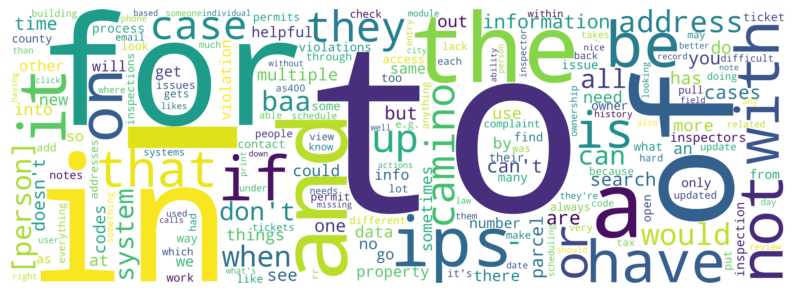

In [18]:
# Word cloud of the challenges for words occurring 3 or more times
from collections import Counter
from wordcloud import WordCloud

# Count all words in the challenge text (simple whitespace split)
all_words = " ".join(df[CHALLENGE_TEXT_COL].values).lower().split()
word_counts = Counter(all_words)

# Filter words that occur at least 3 times
filtered_words = {word: count for word, count in word_counts.items() if count >= 3}

wordcloud = WordCloud(width=6800, height=2400, background_color="white").generate_from_frequencies(filtered_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
# Word cloud of expectations (df is challenges; text lives on expectations_df)
wordcloud = WordCloud(width=6800, height=2400, background_color="white").generate(
    " ".join(expectations_df[EXPECTATION_TEXT_COL].astype(str).values)
)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


## 7. Save categorized outputs


In [ ]:
challenge_cols = [
    c for c in [
        "department", "focus_group", CHALLENGE_TEXT_COL, "processed_text", "source", "sentiment",
        "title", "Category", "Category_Method", "Category_Confidence",
        "Cluster", "Cluster_Label",
    ] if c in df.columns
]
expectation_cols = [
    c for c in [
        "department", "focus_group", EXPECTATION_TEXT_COL, "processed_text", "source", "sentiment",
        "title", "Category", "Category_Method", "Category_Confidence",
    ] if c in expectations_df.columns
]

df[challenge_cols].to_csv(CATEGORIZED_CHALLENGES_CSV, index=False, encoding="utf-8-sig")
expectations_df[expectation_cols].to_csv(
    CATEGORIZED_EXPECTATIONS_CSV, index=False, encoding="utf-8-sig"
)
category_summary = (
    df.groupby("Category", as_index=False).size()
    .rename(columns={"size": "Count"})
    .sort_values("Count", ascending=False)
)
category_summary.to_csv(CATEGORY_SUMMARY_CSV, index=False, encoding="utf-8-sig")

print(f"Saved {CATEGORIZED_CHALLENGES_CSV} ({len(df)} rows)")
print(f"Saved {CATEGORIZED_EXPECTATIONS_CSV} ({len(expectations_df)} rows)")
print(f"Saved {CATEGORY_SUMMARY_CSV}")
display(category_summary)
